In [1]:
import numpy as np
import scipy.stats
import pylab as plt
plt.rcParams['figure.figsize'] = [8, 8]

In [2]:
from urllib.request import urlretrieve
urlretrieve("https://das.sdss.org/va/qsocat/dr7qso.dat", './dr7qso.dat')

('./dr7qso.dat', <http.client.HTTPMessage at 0x2aa88e34e10>)

In [3]:
z= np.loadtxt('dr7qso.dat',skiprows=80, usecols=3)

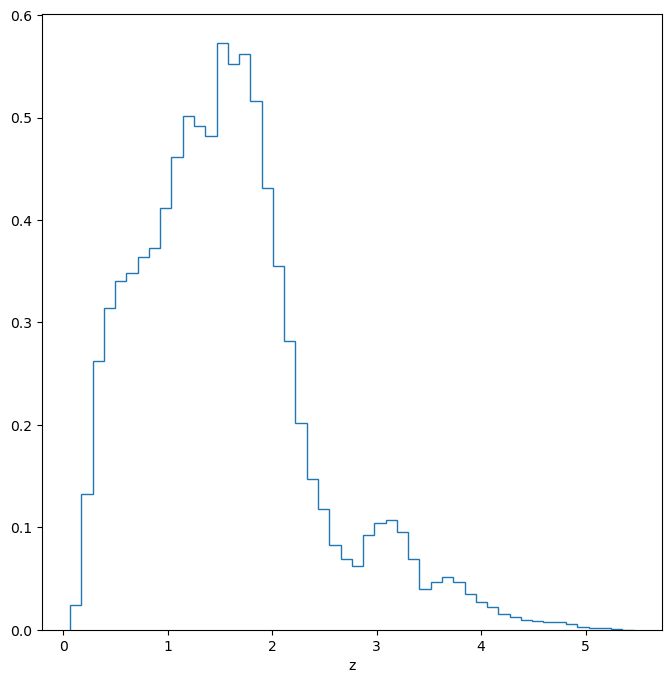

In [10]:
plt.hist(z,bins=50,density=True,histtype='step');
plt.xlabel('z');

### Rejection Sampling

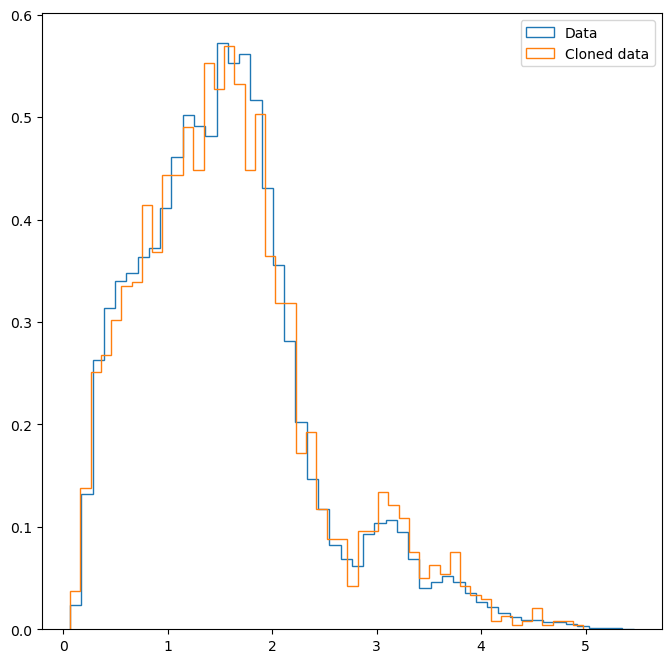

In [14]:
plt.hist(z, bins=50, histtype='step', density=True, label="Data")

y_max = 1

counts, bins = np.histogram(z, bins=50)
disth = scipy.stats.rv_histogram((counts, bins))

N = 100000

q = np.random.uniform(-10, 30, N)
u = np.random.uniform(0, y_max, N)

mask = u <= disth.pdf(q)

monte_carlo = q[mask]

plt.hist(monte_carlo, bins=50, histtype='step', density=True, label='Cloned data')

plt.legend();

### Inverse Transform Sampling

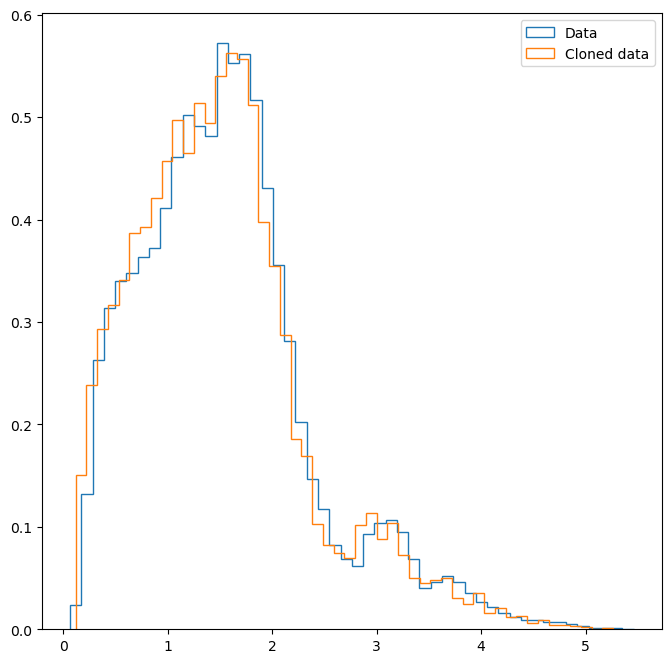

In [15]:
plt.hist(z, bins=50, histtype='step', density=True, label="Data")

counts, bins = np.histogram(z, bins=50)
bin_mids = (bins[1:]+bins[:-1])/2

cdf = np.cumsum(counts)/np.sum(counts)

inv_cdf = scipy.interpolate.interp1d(cdf, bin_mids)

u = np.random.uniform(min(cdf), max(cdf), 10000)
x_sample = inv_cdf(u)

plt.hist(x_sample, bins=50, density = True, histtype='step', label='Cloned data')

plt.legend();